In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as web
import datetime as dt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, InputLayer

In [6]:
import os
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#------------------------------------------------------------------------------
# Production-Ready Multi-Feature Stock Data Loader
#------------------------------------------------------------------------------
def load_and_process_stock_data(
    company="CBA.AX",
    start_date="2020-01-01",
    end_date="2023-08-01",
    data_dir="data",
    handle_nan="drop",       # "drop", "ffill", "bfill", "mean"
    split_method="ratio",    # "ratio", "date", "random"
    split_value=0.8,         # float for ratio, string for date
    scale_features=True,
    scaler_type="standard",  # "standard" or "minmax"
    save_local=True,
    load_local=True
):
    """
    Load, clean, split, and scale stock data (multi-feature) with proper error handling.
    """

    #--------------------------------------------------------------
    # Step 0: Validate dates
    #--------------------------------------------------------------
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    if start_date >= end_date:
        raise ValueError("Start date must be earlier than end date.")

    #--------------------------------------------------------------
    # Step 1: Prepare local file path
    #--------------------------------------------------------------
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
    csv_file = os.path.join(data_dir, f"{company}_stock_data.csv")

    #--------------------------------------------------------------
    # Step 2: Load dataset
    #--------------------------------------------------------------
    data = pd.DataFrame()
    if load_local and os.path.exists(csv_file):
        try:
            data = pd.read_csv(csv_file, index_col="Date", parse_dates=True)
            if data.empty:
                print(f"⚠️ Local file exists but is empty. Will attempt download.")
                data = pd.DataFrame()
            else:
                print(f"✅ Loaded local file: {csv_file}")
        except Exception as e:
            print(f"⚠️ Failed to load local file: {e}. Will attempt download.")

    if data.empty:
        try:
            data = yf.download(company, start=start_date, end=end_date)
            if data.empty:
                raise ValueError("Downloaded dataset is empty. Check ticker or date range.")
            if save_local:
                data.to_csv(csv_file)
                print(f"✅ Downloaded and saved to {csv_file}")
        except Exception as e:
            raise ConnectionError(f"❌ Failed to download data: {e}")

    #--------------------------------------------------------------
    # Step 3: Standardize column names
    #--------------------------------------------------------------
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [col[0] for col in data.columns]  # flatten MultiIndex
    data.columns = data.columns.str.strip().str.title().str.replace(" ", "")

    # Example result: ['Open','High','Low','Close','Adjclose','Volume']

    #--------------------------------------------------------------
    # Step 4: Handle missing values
    #--------------------------------------------------------------
    if handle_nan == "drop":
        data = data.dropna()
    elif handle_nan == "ffill":
        data = data.ffill()
    elif handle_nan == "bfill":
        data = data.bfill()
    elif handle_nan == "mean":
        data = data.fillna(data.mean())
    else:
        raise ValueError("Invalid handle_nan option.")

    #--------------------------------------------------------------
    # Step 5: Feature scaling (per-column)
    #--------------------------------------------------------------
    scalers = {}
    if scale_features:
        scaled_data = pd.DataFrame(index=data.index)
        for col in data.columns:
            if scaler_type == "standard":
                scaler = StandardScaler()
            elif scaler_type == "minmax":
                scaler = MinMaxScaler()
            else:
                raise ValueError("Invalid scaler_type: 'standard' or 'minmax'")
            
            scaled_data[col] = scaler.fit_transform(data[[col]])
            scalers[col] = scaler
        data = scaled_data

    #--------------------------------------------------------------
    # Step 6: Train/Test Split
    #--------------------------------------------------------------
    if split_method == "ratio":
        split_idx = int(len(data) * split_value)
        train = data.iloc[:split_idx]
        test = data.iloc[split_idx:]
    
    elif split_method == "date":
        split_date = pd.to_datetime(split_value)
        train = data[data.index < split_date]
        test = data[data.index >= split_date]
    
    elif split_method == "random":
        train = data.sample(frac=split_value, random_state=42)
        test = data.drop(train.index)
    else:
        raise ValueError("Invalid split_method: 'ratio', 'date', 'random' only")

    return train, test, scalers


#------------------------------------------------------------------------------
# Example Usage
#------------------------------------------------------------------------------
if __name__ == "__main__":
    train_data, test_data, scalers = load_and_process_stock_data(
        company="CBA.AX",
        start_date="2020-01-01",
        end_date="2023-08-01",
        handle_nan="ffill",
        split_method="date",
        split_value="2023-01-01",
        scale_features=True,
        scaler_type="minmax",
        save_local=True,
        load_local=False   # force re-download to avoid empty file issue
    )

    print("Train shape:", train_data.shape)
    print("Test shape:", test_data.shape)
    print("Columns:", train_data.columns.tolist())
    print(train_data.head())


/var/folders/n3/f5ytszns27bb7c95jm3qrfdh0000gn/T/ipykernel_54747/1392883563.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(company, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

✅ Downloaded and saved to data/CBA.AX_stock_data.csv
Train shape: (760, 5)
Test shape: (145, 5)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']
               Close      High       Low      Open    Volume
Date                                                        
2020-01-02  0.354186  0.322016  0.359309  0.335333  0.063919
2020-01-03  0.360430  0.336813  0.371800  0.352911  0.076308
2020-01-06  0.352589  0.316830  0.356985  0.334439  0.106688
2020-01-07  0.373354  0.336965  0.370783  0.350676  0.123976
2020-01-08  0.368998  0.337728  0.368604  0.356635  0.082087


In [7]:
# Select the column you want to predict
PRICE_VALUE = "Close"

# scaled_data is just the values of that column from train_data
scaled_data = train_data[[PRICE_VALUE]].values

PREDICTION_DAYS = 60
x_train, y_train = [], []

for i in range(PREDICTION_DAYS, len(scaled_data)):
    x_train.append(scaled_data[i-PREDICTION_DAYS:i])
    y_train.append(scaled_data[i])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


x_train shape: (700, 60, 1)
y_train shape: (700, 1)


In [8]:
#-------------------- Build the LSTM Model --------------------#
model = Sequential()

# Input layer: shape matches number of past days used for prediction
model.add(InputLayer(input_shape=(x_train.shape[1], 1)))

# First LSTM layer with Dropout for regularization
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Second LSTM layer with Dropout
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Output layer: predicts a single value (next price)
model.add(Dense(1))

# Compile the model with optimizer and loss function
model.compile(optimizer='adam', loss='mean_squared_error')

#-------------------- Train the Model --------------------#
# We train the model on x_train, y_train
# validation_split=0.1 uses 10% of the training data for validation
# verbose=1 prints training progress
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

#-------------------- Save the Model --------------------#
# After training, save the model to reuse later without retraining
model.save("results/CBA_AX_model.h5")


Epoch 1/50


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0886 - val_loss: 0.0424
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0139 - val_loss: 0.0015
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0074 - val_loss: 0.0015
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0071 - val_loss: 0.0021
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0056 - val_loss: 0.0018
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0055 - val_loss: 0.0014
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0056 - val_loss: 0.0016
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0055 - val_loss: 0.0015
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0051 - val_loss: 0.0013
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0047 - val_loss: 0.0012
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0044 - val_l

In [12]:
#------------------------------------------------------------------------------
# Test the model accuracy on existing data
#------------------------------------------------------------------------------
COMPANY = "CBA.AX"
TEST_START = "2020-01-01"
TEST_END = "2023-08-11"

# Download the test data
test_data = yf.download(COMPANY, TEST_START, TEST_END)

# Get actual closing prices
actual_prices = test_data[PRICE_VALUE].values

# Combine training + test column for consistent scaling
total_dataset = pd.concat((train_data[PRICE_VALUE], test_data[PRICE_VALUE]), axis=0)

# Prepare model inputs (last PREDICTION_DAYS from train + all test values)
model_inputs = total_dataset[len(total_dataset) - len(test_data) - PREDICTION_DAYS:].values

# Reshape for scaler
model_inputs = model_inputs.reshape(-1, 1)

# Use same scaler (from training) to transform inputs
scaler = scalers[PRICE_VALUE]   # reuse existing scaler
model_inputs = scaler.transform(model_inputs)

# Prepare x_test sequences
x_test = []
for i in range(PREDICTION_DAYS, len(model_inputs)):
    x_test.append(model_inputs[i - PREDICTION_DAYS:i, 0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Predict
predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)



/var/folders/n3/f5ytszns27bb7c95jm3qrfdh0000gn/T/ipykernel_54747/3804805779.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_data = yf.download(COMPANY, TEST_START, TEST_END)
[*********************100%***********************]  1 of 1 completed

24/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


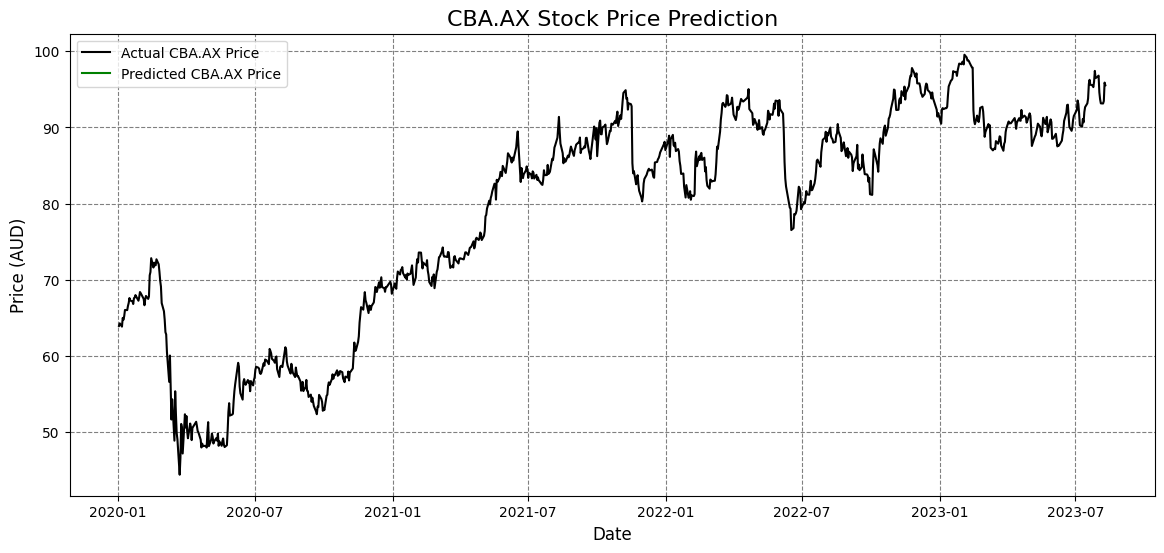

In [13]:
# Trim predicted prices to same length as test_data
predicted_prices = predicted_prices[-len(test_data):]

# Now they align perfectly
plt.figure(figsize=(14, 6))
plt.plot(test_data.index, actual_prices, color="black", label=f"Actual {COMPANY} Price")
plt.plot(test_data.index, predicted_prices, color="green", label=f"Predicted {COMPANY} Price")
plt.title(f"{COMPANY} Stock Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (AUD)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


ValueError: zero-size array to reduction operation maximum which has no identity

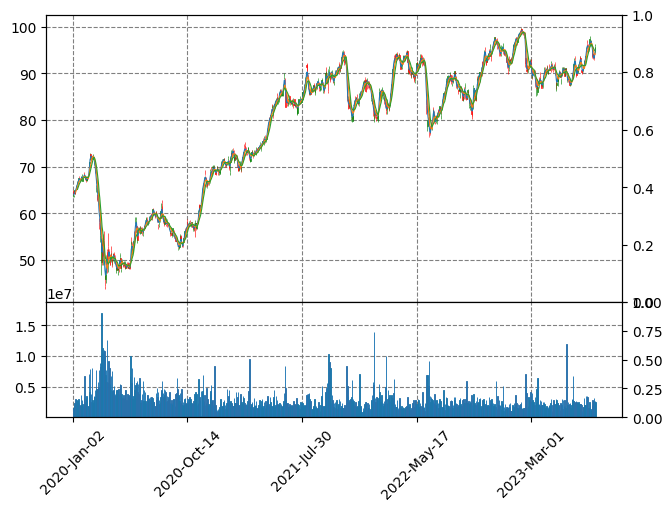

In [14]:
import mplfinance as mpf
import pandas as pd

# Copy test data (OHLCV)
ohlc_data = test_data.copy()

# Flatten MultiIndex columns if present (sometimes happens with yfinance)
if isinstance(ohlc_data.columns, pd.MultiIndex):
    ohlc_data.columns = [col[0] for col in ohlc_data.columns]

# Ensure OHLC columns are numeric
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    if col in ohlc_data.columns:
        ohlc_data[col] = pd.to_numeric(ohlc_data[col], errors='coerce')
    else:
        raise ValueError(f"Column '{col}' not found in test data!")

# Drop NaN rows (important for mplfinance)
ohlc_data.dropna(inplace=True)

# ⚡ FIX: Align predicted prices with test data length
predicted_prices = predicted_prices[-len(ohlc_data):]

# Create a series of predicted prices aligned to the last N rows of ohlc_data
ohlc_data['Predicted'] = pd.Series(
    predicted_prices.flatten(),
    index=ohlc_data.index[-len(predicted_prices):]
)

# Custom style for candlesticks
mc = mpf.make_marketcolors(up='g', down='r', edge='i', wick='i', volume='in')
s = mpf.make_mpf_style(marketcolors=mc, gridstyle='--', gridcolor='gray')

# Create an additional plot (Predicted line overlay)
add_plot = mpf.make_addplot(ohlc_data['Predicted'], color='blue', width=1.2)

# Plot candlestick chart with predicted prices overlay
mpf.plot(
    ohlc_data,
    type='candle',
    style=s,
    title=f"{COMPANY} Candlestick Chart with Predicted Prices",
    ylabel='Price (AUD)',
    volume=True,
    mav=(3, 6, 9),          # Moving averages (3, 6, 9 days)
    addplot=add_plot        # Overlay predicted prices
)


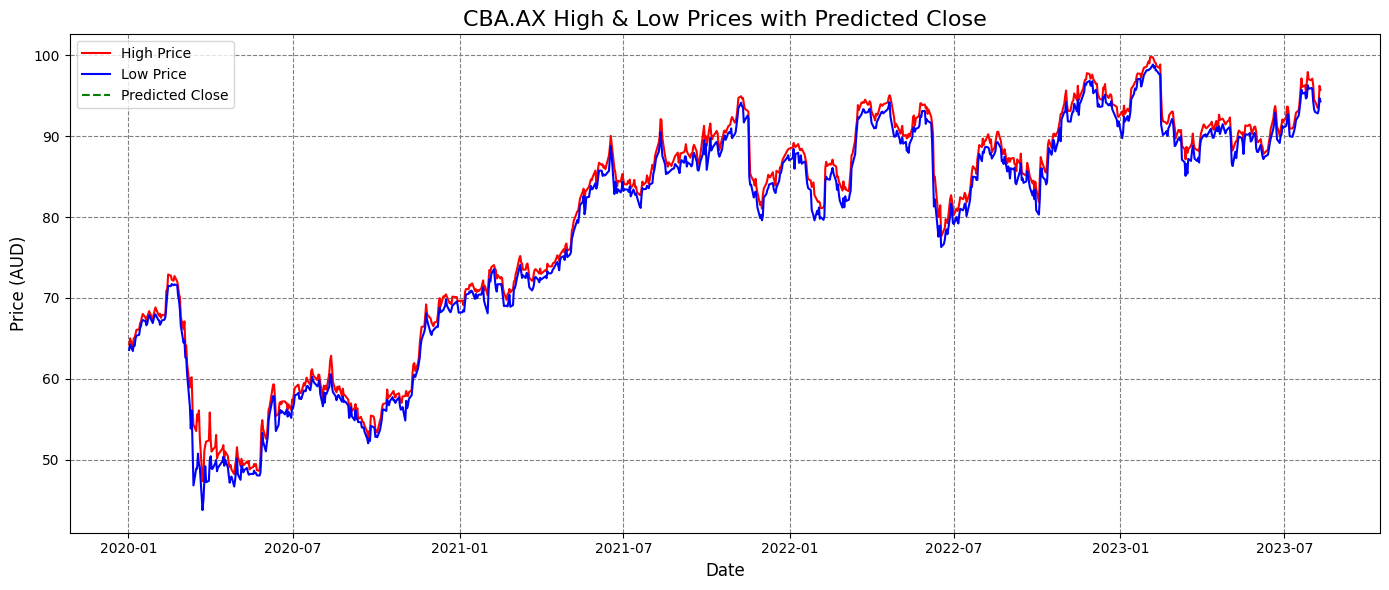

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Plot daily High prices
plt.plot(test_data.index, test_data['High'], color='red', label='High Price')

# Plot daily Low prices
plt.plot(test_data.index, test_data['Low'], color='blue', label='Low Price')

# Optional: overlay predicted Close prices
plt.plot(test_data.index, predicted_prices, color='green', linestyle='--', label='Predicted Close')

# Titles and labels
plt.title(f"{COMPANY} High & Low Prices with Predicted Close", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (AUD)", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, GRU, SimpleRNN, InputLayer

def build_dl_model(
    input_shape,
    layer_type="LSTM",       # choose: "LSTM", "GRU", or "RNN"
    layer_sizes=(50, 50),    # hidden units per layer
    dropout_rate=0.2,
    output_size=1,
    optimizer="adam",
    loss="mean_squared_error"
):
    """
    Build and compile a Deep Learning model dynamically.

    Parameters
    ----------
    input_shape : tuple
        Shape of the input (timesteps, features).
    layer_type : str
        Type of recurrent layer: "LSTM", "GRU", or "RNN".
    layer_sizes : tuple
        Number of units in each layer. Length = number of layers.
    dropout_rate : float
        Dropout rate after each recurrent layer.
    output_size : int
        Size of output layer (1 for regression).
    optimizer : str
        Optimizer to use for training.
    loss : str
        Loss function.

    Returns
    -------
    model : keras.Sequential
        A compiled Keras model ready for training.
    """

    # Map layer type to actual Keras layer
    if layer_type == "LSTM":
        RNNLayer = LSTM
    elif layer_type == "GRU":
        RNNLayer = GRU
    elif layer_type in ("RNN", "SimpleRNN"):
        RNNLayer = SimpleRNN
    else:
        raise ValueError("layer_type must be 'LSTM', 'GRU', or 'RNN'.")

    model = Sequential()
    model.add(InputLayer(input_shape=input_shape))

    # Add recurrent layers dynamically
    for i, units in enumerate(layer_sizes):
        return_seq = (i < len(layer_sizes) - 1)   # only last layer returns final output
        model.add(RNNLayer(units, return_sequences=return_seq))
        model.add(Dropout(dropout_rate))

    # Final output layer
    model.add(Dense(output_size))

    # Compile model
    model.compile(optimizer=optimizer, loss=loss)
    return model


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd

results = []

configs = [
    {"layer_type": "LSTM", "layer_sizes": (50, 50), "dropout": 0.2, "epochs": 20, "batch": 32},
    {"layer_type": "GRU",  "layer_sizes": (64, 32), "dropout": 0.3, "epochs": 20, "batch": 32},
    {"layer_type": "RNN",  "layer_sizes": (30,),    "dropout": 0.1, "epochs": 20, "batch": 32},
    {"layer_type": "LSTM", "layer_sizes": (128, 64),"dropout": 0.3, "epochs": 30, "batch": 64},
]

for cfg in configs:
    print(f"\n=== Training {cfg['layer_type']} {cfg['layer_sizes']} ===")
    model = build_dl_model(
        input_shape=(x_train.shape[1], x_train.shape[2]),
        layer_type=cfg["layer_type"],
        layer_sizes=cfg["layer_sizes"],
        dropout_rate=cfg["dropout"]
    )
    
    history = model.fit(
        x_train, y_train,
        epochs=cfg["epochs"],
        batch_size=cfg["batch"],
        validation_split=0.1,
        verbose=0
    )
    
    # Predict on training data just for comparison (you can adapt for test later)
    preds = model.predict(x_train, verbose=0)
    
    mae = mean_absolute_error(y_train, preds)
    mse = mean_squared_error(y_train, preds)
    
    results.append({
        "Model": cfg["layer_type"],
        "Layers": cfg["layer_sizes"],
        "Dropout": cfg["dropout"],
        "Epochs": cfg["epochs"],
        "Batch": cfg["batch"],
        "MAE": round(mae, 4),
        "MSE": round(mse, 4)
    })

# Summarize results
results_df = pd.DataFrame(results)
print(results_df)



=== Training LSTM (50, 50) ===


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



=== Training GRU (64, 32) ===


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



=== Training RNN (30,) ===


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



=== Training LSTM (128, 64) ===


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


  Model     Layers  Dropout  Epochs  Batch     MAE     MSE
0  LSTM   (50, 50)      0.2      20     32  0.0296  0.0015
1   GRU   (64, 32)      0.3      20     32  0.0220  0.0008
2   RNN      (30,)      0.1      20     32  0.0249  0.0010
3  LSTM  (128, 64)      0.3      30     64  0.0291  0.0015


In [18]:
import numpy as np
def univariate_multistep(series_2d,sq_len=60,k_step=5):
    X,y=[],[]
    for i in range(seq_len,len(series_2d)-k_steps+1):
        X.append(series_2d[i-seq_len:i,:])
        y.append(series_2d[i:i +k_steps,o])
    return np.array(X),np.array(y)

In [19]:
def make_sequences_multivariate_singlestep(df_scaled, input_cols, target_col, seq_len=60):
    X, y = [], []
    inputs = df_scaled[input_cols].values
    target = df_scaled[[target_col]].values
    for i in range(seq_len, len(df_scaled)):
        X.append(inputs[i - seq_len:i, :])  # shape: (seq_len, n_features)
        y.append(target[i, 0])              # scalar target
    return np.array(X), np.array(y).reshape(-1, 1)


# (3) Multivariate Multistep
def make_sequences_multivariate_multistep(df_scaled, input_cols, target_col, seq_len=60, k_steps=5):
    X, y = [], []
    inputs = df_scaled[input_cols].values
    target = df_scaled[[target_col]].values
    for i in range(seq_len, len(df_scaled) - k_steps + 1):
        X.append(inputs[i - seq_len:i, :])   # shape: (seq_len, n_features)
        y.append(target[i:i + k_steps, 0])   # shape: (k,)
    return np.array(X), np.array(y)


In [20]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, GRU, SimpleRNN, InputLayer
from statsmodels.tsa.arima.model import ARIMA

# -------------------------------
# Build DL model
# -------------------------------
def build_dl_model(
    input_shape,
    layer_type="LSTM",
    layer_sizes=(50, 50),
    dropout_rate=0.2,
    output_size=1,
    optimizer="adam",
    loss="mean_squared_error"
):
    if layer_type == "LSTM":
        RNNLayer = LSTM
    elif layer_type == "GRU":
        RNNLayer = GRU
    elif layer_type in ("RNN", "SimpleRNN"):
        RNNLayer = SimpleRNN
    else:
        raise ValueError("layer_type must be 'LSTM', 'GRU', or 'RNN'.")

    model = Sequential()
    model.add(InputLayer(input_shape=input_shape))

    for i, units in enumerate(layer_sizes):
        return_seq = (i < len(layer_sizes) - 1)
        model.add(RNNLayer(units, return_sequences=return_seq))
        model.add(Dropout(dropout_rate))

    model.add(Dense(output_size))
    model.compile(optimizer=optimizer, loss=loss)
    return model

# -------------------------------
# Main Ensemble Pipeline
# -------------------------------
def run_ensemble_pipeline(df, seq_len=60, epochs=20, batch_size=32):
    input_cols = ['Open','High','Low','Close','Volume']
    target_col = 'Close'

    # Scale features
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df[input_cols]),
        columns=input_cols,
        index=df.index
    )

    # Make sequences (your existing function)
    X, y = make_sequences_multivariate_singlestep(df_scaled, input_cols, target_col, seq_len=seq_len)

    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # -------------------------------
    # Train LSTM
    # -------------------------------
    model_lstm = build_dl_model((seq_len, len(input_cols)), layer_type="LSTM", layer_sizes=(64, 32))
    model_lstm.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)

    # Predict with LSTM (still scaled)
    lstm_pred_scaled = model_lstm.predict(X_test)

    # -------------------------------
    # Inverse transform predictions & actuals (Close only)
    # -------------------------------
    close_idx = input_cols.index("Close")

    # Actual values
    temp_actual = np.zeros((len(y_test), len(input_cols)))
    temp_actual[:, close_idx] = y_test.ravel()
    actual = scaler.inverse_transform(temp_actual)[:, close_idx]

    # LSTM predictions
    temp_lstm = np.zeros((len(lstm_pred_scaled), len(input_cols)))
    temp_lstm[:, close_idx] = lstm_pred_scaled.ravel()
    lstm_pred = scaler.inverse_transform(temp_lstm)[:, close_idx]

    # -------------------------------
    # Train ARIMA (on raw close prices, not scaled)
    # -------------------------------
    close_prices = df['Close'].values
    train_close, test_close = close_prices[:split+seq_len], close_prices[split+seq_len:]

    arima_model = ARIMA(train_close, order=(5,1,0))
    arima_fit = arima_model.fit()
    arima_pred = arima_fit.forecast(steps=len(test_close))

    # -------------------------------
    # Align predictions
    # -------------------------------
    min_len = min(len(test_close), len(lstm_pred), len(arima_pred))
    actual = test_close[:min_len]
    lstm_pred = lstm_pred[:min_len]
    arima_pred = arima_pred[:min_len]

    # Simple ensemble (average)
    ensemble_pred = (lstm_pred + arima_pred) / 2

    # -------------------------------
    # Metrics
    # -------------------------------
    results = {
        "ARIMA_MAE": mean_absolute_error(actual, arima_pred),
        "LSTM_MAE": mean_absolute_error(actual, lstm_pred),
        "Ensemble_MAE": mean_absolute_error(actual, ensemble_pred),
        "ARIMA_MSE": mean_squared_error(actual, arima_pred),
        "LSTM_MSE": mean_squared_error(actual, lstm_pred),
        "Ensemble_MSE": mean_squared_error(actual, ensemble_pred),
    }

    return results, actual, lstm_pred, arima_pred, ensemble_pred


In [21]:
import matplotlib.pyplot as plt

def plot_ensemble_results(actual, arima_pred, lstm_pred, ensemble_pred, company="Stock"):
    # Align everything to the shortest length
    min_len = min(len(actual), len(arima_pred), len(lstm_pred), len(ensemble_pred))
    actual = actual[:min_len]
    arima_pred = arima_pred[:min_len]
    lstm_pred = lstm_pred[:min_len]
    ensemble_pred = ensemble_pred[:min_len]

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(actual, color="black", label="Actual Prices", linewidth=1.5)
    plt.plot(arima_pred, color="green", label="ARIMA Predictions", linewidth=1)
    plt.plot(lstm_pred, color="blue", label="LSTM Predictions", linewidth=1)
    plt.plot(ensemble_pred, color="red", linestyle="--", label="Ensemble (Avg)", linewidth=1.5)

    plt.title(f"{company} Stock Price Prediction - Ensemble vs Models")
    plt.xlabel("Time Steps")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()


In [22]:
import pandas as pd

df = pd.read_csv("data/CBA.AX_stock_data.csv", skiprows=2)

print(df.head())
print(df.shape)
print(df.columns)


         Date  Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5
0  2020-01-02   63.946312   64.218495   63.554054   63.874267     1416232
1  2020-01-03   64.290550   64.995020   64.242520   64.818903     1622784
2  2020-01-06   63.858257   63.946316   63.425977   63.826241     2129260
3  2020-01-07   65.002998   65.002998   64.186461   64.698799     2417468
4  2020-01-08   64.762863   65.043047   64.066400   65.019032     1719114
(905, 6)
Index(['Date', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5'],
      dtype='object')


In [23]:
import pandas as pd

# Load and skip the first 2 metadata rows
df = pd.read_csv("data/CBA.AX_stock_data.csv", skiprows=2)

# Rename columns properly
df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

# Convert Date column to datetime and set as index
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df.set_index("Date", inplace=True)

print(df.head())
print(df.columns)


                Close       High        Low       Open   Volume
Date                                                           
2020-01-02  63.946312  64.218495  63.554054  63.874267  1416232
2020-01-03  64.290550  64.995020  64.242520  64.818903  1622784
2020-01-06  63.858257  63.946316  63.425977  63.826241  2129260
2020-01-07  65.002998  65.002998  64.186461  64.698799  2417468
2020-01-08  64.762863  65.043047  64.066400  65.019032  1719114
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0609
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0111
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0088
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0086
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0079
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0067
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0072
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0070
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0059
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0059
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0064
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0058
Epoch 13/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0067
Epoch 14/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0069
Epoch 15/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0067
Epoc

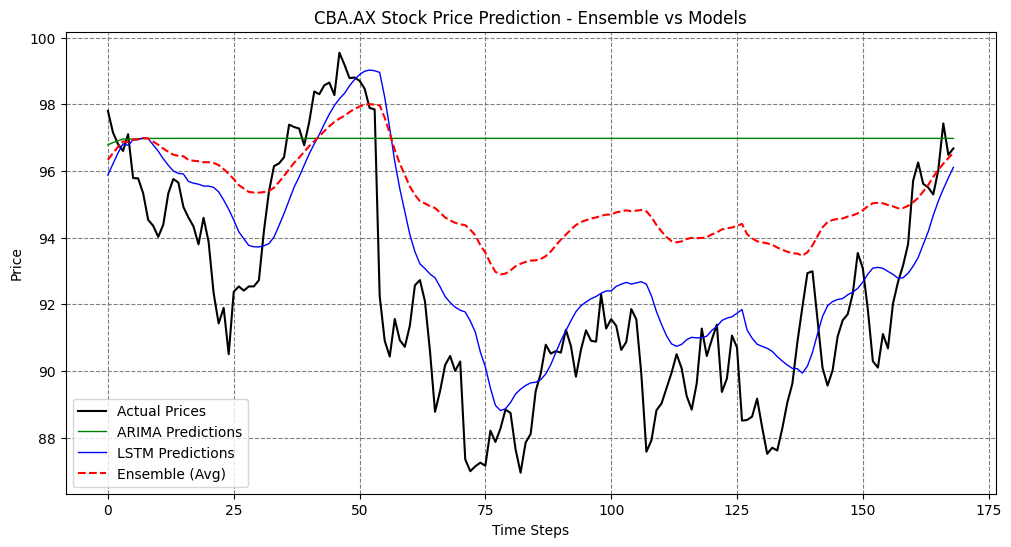

In [24]:
# Run pipeline first (make sure df is defined!)
results, actual, lstm_pred, arima_pred, ensemble_pred = run_ensemble_pipeline(df)

# Print numeric metrics (MAE & MSE)
print(results)

# Plot predictions
plot_ensemble_results(actual, arima_pred, lstm_pred, ensemble_pred, company="CBA.AX")


In [ ]:
pip install newsapi-python transformers torch


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import numpy as np

# Load your stock dataset
df_stock = pd.read_csv("data/CBA.AX_stock_data.csv", skiprows=2)
df_stock["Date"] = pd.to_datetime(df_stock["Date"])
df_stock.set_index("Date", inplace=True)

print(df_stock.head())


            Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5
Date                                                                  
2020-01-02   63.946312   64.218495   63.554054   63.874267     1416232
2020-01-03   64.290550   64.995020   64.242520   64.818903     1622784
2020-01-06   63.858257   63.946316   63.425977   63.826241     2129260
2020-01-07   65.002998   65.002998   64.186461   64.698799     2417468
2020-01-08   64.762863   65.043047   64.066400   65.019032     1719114


In [26]:
import pandas as pd

# Load and skip the first 2 metadata rows
df = pd.read_csv("data/CBA.AX_stock_data.csv", skiprows=2)

# Rename columns properly
df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

# Convert Date column to datetime and set as index
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df.set_index("Date", inplace=True)

print(df.head())
print(df.columns)


                Close       High        Low       Open   Volume
Date                                                           
2020-01-02  63.946312  64.218495  63.554054  63.874267  1416232
2020-01-03  64.290550  64.995020  64.242520  64.818903  1622784
2020-01-06  63.858257  63.946316  63.425977  63.826241  2129260
2020-01-07  65.002998  65.002998  64.186461  64.698799  2417468
2020-01-08  64.762863  65.043047  64.066400  65.019032  1719114
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [27]:
pip install tf-keras



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd
from transformers import pipeline

# 1) Load stock data
df = pd.read_csv("data/CBA.AX_stock_data.csv", skiprows=2)
df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df.set_index("Date", inplace=True)

# 2) Load financial news dataset
df_news = pd.read_csv(
    "data/financial-news.csv",
    header=None,
    names=["Label", "Headline"],   # Label ignored, using FinBERT
    encoding="latin1"
)

# 3) Initialize FinBERT (force PyTorch to avoid Keras error)
finbert = pipeline("sentiment-analysis", 
                   model="yiyanghkust/finbert-tone", 
                   framework="pt")

# 4) Run FinBERT on headlines
df_news["finbert_result"] = df_news["Headline"].apply(lambda x: finbert(x)[0])
df_news["finbert_label"] = df_news["finbert_result"].apply(lambda x: x['label'])
df_news["finbert_score"] = df_news["finbert_result"].apply(lambda x: x['score'])

# 5) Map labels to numeric sentiment (case-insensitive fix)
df_news["sentiment"] = df_news["finbert_label"].str.lower().map(
    {"positive": 1, "neutral": 0, "negative": -1}
)

# 6) Assign fake sequential dates (since dataset has no dates)
df_news["Date"] = pd.date_range(start=df.index.min(), periods=len(df_news), freq="D")

# 7) Aggregate daily sentiment
df_sent_daily = df_news.groupby("Date")["sentiment"].mean().to_frame()

# 8) Merge with stock data
df_merged = df.join(df_sent_daily, how="left")
df_merged["sentiment"] = df_merged["sentiment"].fillna(0)

# 9) Reset index for ML usage
df_merged = df_merged.reset_index()[["Date", "Open", "High", "Low", "Close", "Volume", "sentiment"]]

# 10) Create classification target
df_merged["Target"] = (df_merged["Close"].shift(-1) > df_merged["Close"]).astype(int)
df_merged = df_merged.dropna()

print(df_news[["Headline", "finbert_label", "sentiment"]].head(10))
print(df_merged.head())
print(df_merged.shape)


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use mps:0


                                            Headline finbert_label  sentiment
0  According to Gran , the company has no plans t...       Neutral          0
1  Technopolis plans to develop in stages an area...       Neutral          0
2  The international electronic industry company ...       Neutral          0
3  With the new production plant the company woul...      Positive          1
4  According to the company 's updated strategy f...      Positive          1
5  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...      Positive          1
6  For the last quarter of 2010 , Componenta 's n...      Positive          1
7  In the third quarter of 2010 , net sales incre...      Positive          1
8  Operating profit rose to EUR 13.1 mn from EUR ...      Positive          1
9  Operating profit totalled EUR 21.1 mn , up fro...      Positive          1
        Date       Open       High        Low      Close   Volume  sentiment  \
0 2020-01-02  63.874267  64.218495  63.554054  63.946312  1416

In [29]:
print(df_news[["Headline", "finbert_label", "finbert_score"]].head(10))


                                            Headline finbert_label  \
0  According to Gran , the company has no plans t...       Neutral   
1  Technopolis plans to develop in stages an area...       Neutral   
2  The international electronic industry company ...       Neutral   
3  With the new production plant the company woul...      Positive   
4  According to the company 's updated strategy f...      Positive   
5  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...      Positive   
6  For the last quarter of 2010 , Componenta 's n...      Positive   
7  In the third quarter of 2010 , net sales incre...      Positive   
8  Operating profit rose to EUR 13.1 mn from EUR ...      Positive   
9  Operating profit totalled EUR 21.1 mn , up fro...      Positive   

   finbert_score  
0       0.999982  
1       1.000000  
2       0.999511  
3       1.000000  
4       0.995748  
5       0.999859  
6       1.000000  
7       1.000000  
8       0.999992  
9       0.994542  


In [30]:
# 7) Create classification target (1 = price up next day, 0 = price down or same)
df_merged["Target"] = (df_merged["Close"].shift(-1) > df_merged["Close"]).astype(int)

# Drop last row (no next day data available)
df_merged = df_merged.dropna()

print(df_merged[["Date", "Close", "sentiment", "Target"]].head(10))


        Date      Close  sentiment  Target
0 2020-01-02  63.946312        0.0       1
1 2020-01-03  64.290550        0.0       0
2 2020-01-06  63.858257        1.0       1
3 2020-01-07  65.002998        1.0       0
4 2020-01-08  64.762863        1.0       1
5 2020-01-09  65.235168        1.0       1
6 2020-01-10  66.043694        1.0       0
7 2020-01-13  66.027695        0.0       1
8 2020-01-14  66.580055        0.0       1
9 2020-01-15  66.972321        1.0       1


In [31]:
from sklearn.model_selection import train_test_split

# Features (without sentiment, baseline)
X_base = df_merged[["Open", "High", "Low", "Close", "Volume"]]
y = df_merged["Target"]

# Features (with sentiment)
X_sent = df_merged[["Open", "High", "Low", "Close", "Volume", "sentiment"]]

# Train-test split
Xb_train, Xb_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, shuffle=False)
Xs_train, Xs_test, _, _ = train_test_split(X_sent, y, test_size=0.2, shuffle=False)


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Baseline model (no sentiment)
logreg_base = LogisticRegression(max_iter=1000)
logreg_base.fit(Xb_train, y_train)
y_pred_base = logreg_base.predict(Xb_test)

print("Baseline Model (No Sentiment):")
print(classification_report(y_test, y_pred_base))
print(confusion_matrix(y_test, y_pred_base))


Baseline Model (No Sentiment):
              precision    recall  f1-score   support

           0       0.33      0.02      0.04        86
           1       0.52      0.96      0.67        95

    accuracy                           0.51       181
   macro avg       0.43      0.49      0.36       181
weighted avg       0.43      0.51      0.37       181

[[ 2 84]
 [ 4 91]]


In [33]:
import pandas as pd
import numpy as np

def compute_rsi(series, period=14):
    """Calculate the Relative Strength Index (RSI) for a given price series."""
    delta = series.diff()

    # Gains (up moves) and losses (down moves)
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Exponential moving averages of gains and losses
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()

    rs = avg_gain / (avg_loss + 1e-10)  # avoid division by zero
    rsi = 100 - (100 / (1 + rs))
    return rsi


In [34]:
# Add indicators
df_merged["SMA_5"] = df_merged["Close"].rolling(5).mean()
df_merged["SMA_10"] = df_merged["Close"].rolling(10).mean()
df_merged["RSI_14"] = compute_rsi(df_merged["Close"], 14)

# Drop NaNs caused by rolling
df_merged = df_merged.dropna()


In [35]:
# Extended feature set = OHLCV + sentiment + indicators
X_sent_ext = df_merged[[
    "Open", "High", "Low", "Close", "Volume",
    "sentiment", "SMA_5", "SMA_10", "RSI_14"
]].dropna()

# Target (aligned with feature rows)
y_ext = df_merged.loc[X_sent_ext.index, "Target"]


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sent_ext, y_ext, test_size=0.2, shuffle=False
)


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train-test split (use same indexing as before)
X_train, X_test, y_train, y_test = train_test_split(
    X_sent_ext, y_ext, test_size=0.2, shuffle=False
)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Model:")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Model:
              precision    recall  f1-score   support

           0       0.52      0.74      0.61        85
           1       0.61      0.37      0.46        94

    accuracy                           0.55       179
   macro avg       0.57      0.56      0.54       179
weighted avg       0.57      0.55      0.53       179

[[63 22]
 [59 35]]


In [ ]:
!pip install xgboost

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Model:")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))


XGBoost Model:
              precision    recall  f1-score   support

           0       0.51      0.71      0.59        85
           1       0.60      0.39      0.47        94

    accuracy                           0.54       179
   macro avg       0.55      0.55      0.53       179
weighted avg       0.56      0.54      0.53       179

[[60 25]
 [57 37]]


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:49:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [40]:
# Use the same y (target) for both
y = df_merged["Target"]

# Define splits once
X_base = df_merged[["Open", "High", "Low", "Close", "Volume"]]
X_sent = df_merged[["Open", "High", "Low", "Close", "Volume", "sentiment"]]

Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, shuffle=False
)

Xs_train, Xs_test, _, _ = train_test_split(
    X_sent, y, test_size=0.2, shuffle=False
)

# Baseline Logistic
logreg_base = LogisticRegression(max_iter=1000)
logreg_base.fit(Xb_train, y_train)
y_pred_base = logreg_base.predict(Xb_test)

# Sentiment Logistic
logreg_sent = LogisticRegression(max_iter=1000)
logreg_sent.fit(Xs_train, y_train)
y_pred_sent = logreg_sent.predict(Xs_test)


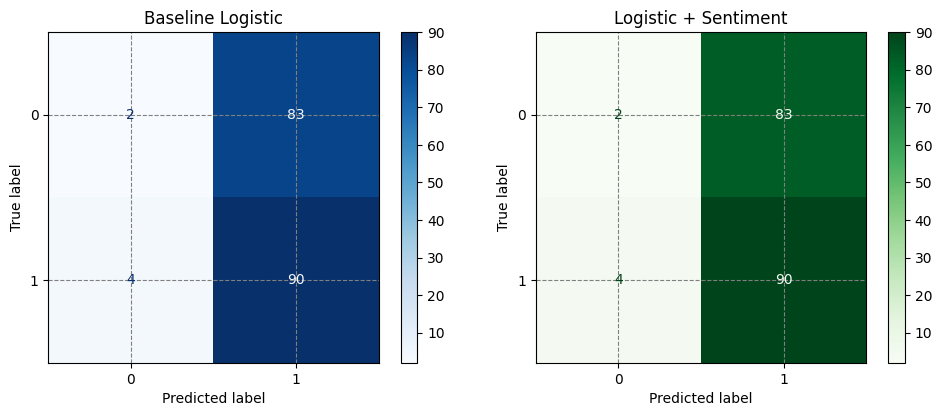

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Baseline Logistic
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, ax=axes[0], cmap="Blues")
axes[0].set_title("Baseline Logistic")

# Logistic + Sentiment
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sent, ax=axes[1], cmap="Greens")
axes[1].set_title("Logistic + Sentiment")

plt.tight_layout()
plt.show()


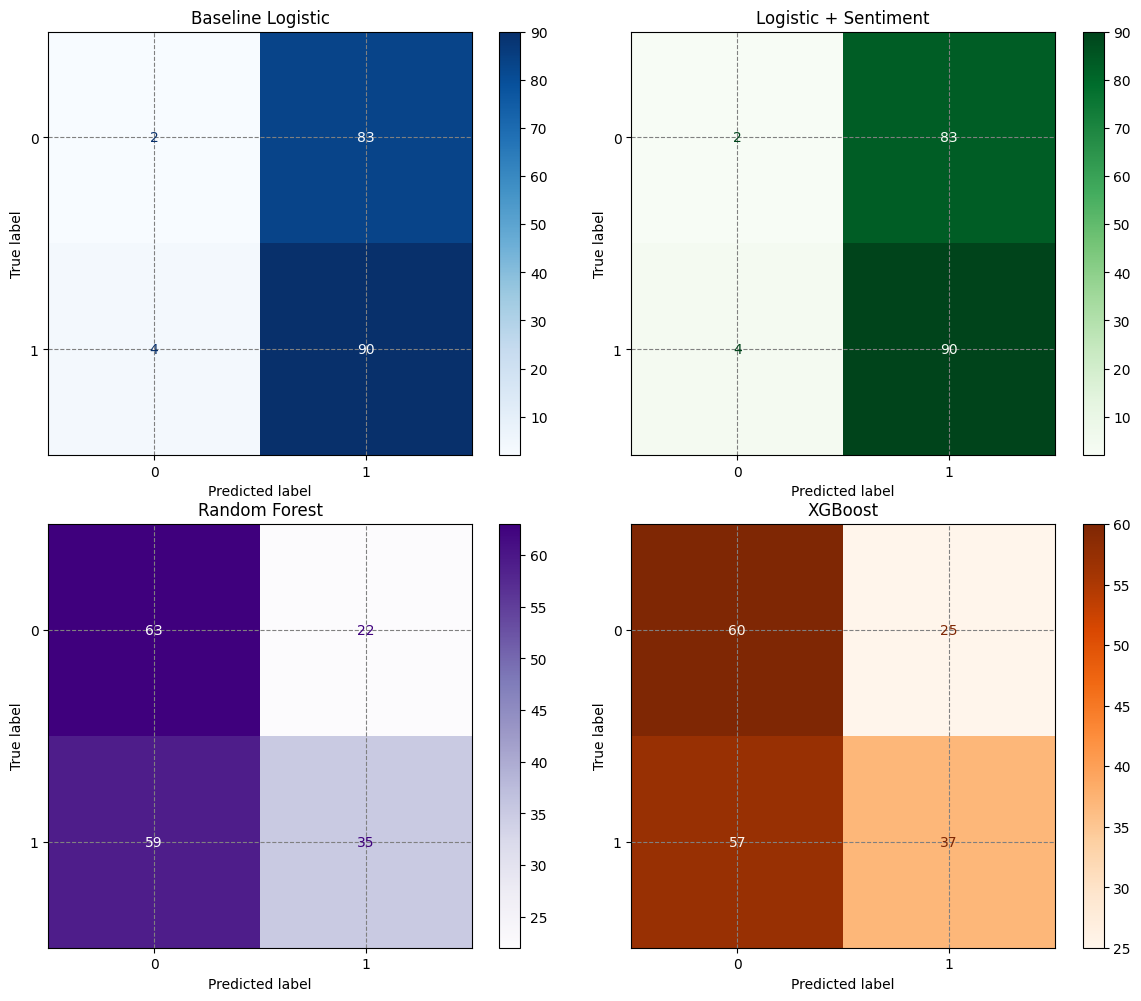

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# Baseline Logistic
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, ax=axes[0,0], cmap="Blues")
axes[0,0].set_title("Baseline Logistic")

# Logistic + Sentiment
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sent, ax=axes[0,1], cmap="Greens")
axes[0,1].set_title("Logistic + Sentiment")

# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1,0], cmap="Purples")
axes[1,0].set_title("Random Forest")

# XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[1,1], cmap="Oranges")
axes[1,1].set_title("XGBoost")

plt.tight_layout()
plt.show()


In [43]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate classification reports as dicts
report_base = classification_report(y_test, y_pred_base, output_dict=True)
report_sent = classification_report(y_test, y_pred_sent, output_dict=True)
report_rf   = classification_report(y_test, y_pred_rf, output_dict=True)
report_xgb  = classification_report(y_test, y_pred_xgb, output_dict=True)

# Extract macro avg (or weighted avg if you prefer)
results = pd.DataFrame({
    "Baseline Logistic": report_base["macro avg"],
    "Logistic+Sentiment": report_sent["macro avg"],
    "Random Forest": report_rf["macro avg"],
    "XGBoost": report_xgb["macro avg"]
})

# Keep only main metrics
results = results.loc[["precision", "recall", "f1-score"]]

print(results)


           Baseline Logistic  Logistic+Sentiment  Random Forest   XGBoost
precision           0.426782            0.426782       0.565214  0.554797
recall              0.490488            0.490488       0.556758  0.549750
f1-score            0.359057            0.359057       0.536136  0.534209
